In [1]:
TRAIN_DIR = '/kaggle/input/gtsrb-german-traffic-sign'
TEST_DIR = '/kaggle/input/gtsrb-german-traffic-sign'
TRAIN_CSV = '/kaggle/input/gtsrb-german-traffic-sign/Train.csv'
TEST_CSV = '/kaggle/input/gtsrb-german-traffic-sign/Test.csv'

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os 

ClassId
11    1320
12    2100
13    2160
14     780
15     630
16     420
17    1110
18    1200
19     210
20     360
Name: count, dtype: int64


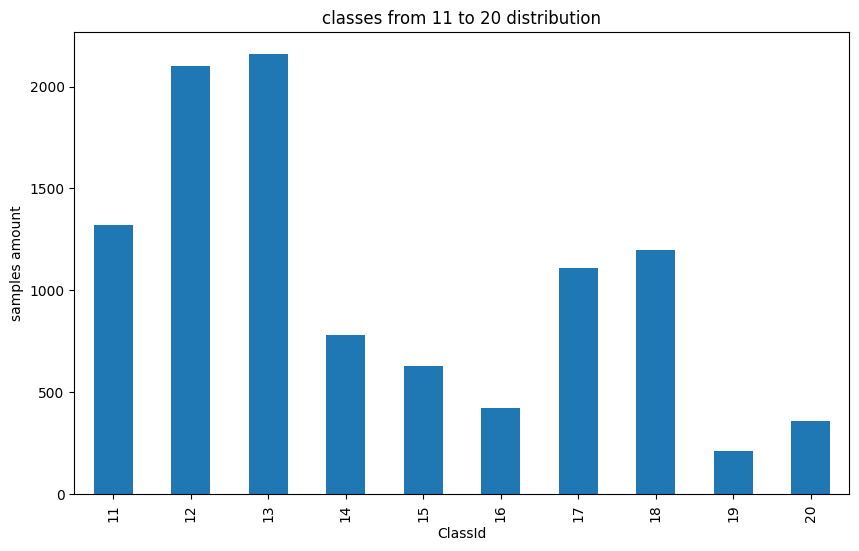

In [3]:

df = pd.read_csv(TRAIN_CSV)

# lấy từ class 11 đến 20
filtered_df = df[df['ClassId'].between(11, 20)]


class_counts = filtered_df['ClassId'].value_counts().sort_index()
print(class_counts)


plt.figure(figsize=(10, 6))
class_counts.plot(kind='bar')
plt.xlabel('ClassId')
plt.ylabel('samples amount')
plt.title('classes from 11 to 20 distribution')
plt.show()

In [12]:
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision.models import resnet18

# 

In [15]:

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

#  pre-trained ResNet18 \
model = resnet18(pretrained=True)
model.to(device)


model.fc = torch.nn.Linear(model.fc.in_features, 10)
model.to(device)  


batch_size = 64
learning_rate = 0.001
epochs = 5


criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
print(model)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 170MB/s] 


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [6]:

save_path = 'resnet18_gtsrb_epoch_{}.pt'

def save_model(model, epoch):
    torch.save(model.state_dict(), save_path.format(epoch))
    print(f'saved at epoch {epoch}')

In [7]:
from sklearn.model_selection import train_test_split

# data preparation
image_paths = []
labels = []
for _, row in filtered_df.iterrows():
    path = os.path.join(TRAIN_DIR, row['Path'])
    label = row['ClassId'] - 11  #  class 11-20 ->  0-9
    image_paths.append(path)
    labels.append(label)


train_paths, val_paths, train_labels, val_labels = train_test_split(
    image_paths, labels, test_size=0.2, stratify=labels, random_state=42
)

print(f'Train samples: {len(train_paths)}, Validation samples: {len(val_paths)}')

Train samples: 8232, Validation samples: 2058


In [6]:
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

In [10]:

class TrafficSignDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

In [13]:

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


In [11]:

train_dataset = TrafficSignDataset(train_paths, train_labels, transform=transform)
val_dataset = TrafficSignDataset(val_paths, val_labels, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [12]:

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

Epoch 1/5: 100%|██████████| 129/129 [01:50<00:00,  1.17it/s]


Epoch 1: Train loss: 0.07685666865138553, Train accuracy: 97.69193391642371%, Validation loss: 0.024778852256889822, Val Acc: 99.22254616132167%
saved at epoch 1


Epoch 2/5: 100%|██████████| 129/129 [00:35<00:00,  3.67it/s]


Epoch 2: Train loss: 0.007199863635424106, Train accuracy: 99.86637512147716%, Validation loss: 0.0035633516114709587, Val Acc: 99.85422740524781%
saved at epoch 2


Epoch 3/5: 100%|██████████| 129/129 [00:34<00:00,  3.74it/s]


Epoch 3: Train loss: 0.01611495054701015, Train accuracy: 99.59912536443149%, Validation loss: 0.0546438607852906, Val Acc: 98.54227405247813%
saved at epoch 3


Epoch 4/5: 100%|██████████| 129/129 [00:34<00:00,  3.76it/s]


Epoch 4: Train loss: 0.002746735280853436, Train accuracy: 99.92711370262391%, Validation loss: 0.0005600274310409352, Val Acc: 100.0%
saved at epoch 4


Epoch 5/5: 100%|██████████| 129/129 [00:34<00:00,  3.73it/s]


Epoch 5: Train loss: 0.0002482095326338949, Train accuracy: 100.0%, Validation loss: 0.0004170944046315774, Val Acc: 100.0%
saved at epoch 5


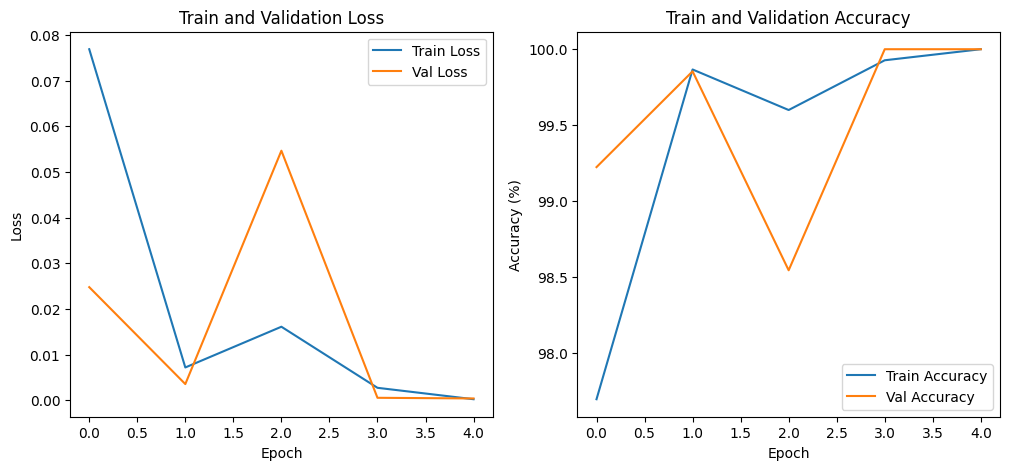

In [13]:
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import logging



for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs}'):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    
   
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
    
    val_loss /= len(val_loader)
    val_acc = 100 * correct_val / total_val
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    
    
    epoch_log = f'Epoch {epoch+1}: Train loss: {train_loss}, Train accuracy: {train_acc}%, Validation loss: {val_loss}, Val Acc: {val_acc}%'
    print(epoch_log)
    # logging.info(epoch_log)
    
    
    save_model(model, epoch+1)


plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train and Validation Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Train and Validation Accuracy')
plt.legend()

plt.show()

In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

test_df = pd.read_csv(TEST_CSV)
test_filtered_df = test_df[test_df['ClassId'].between(11, 20)]

test_image_paths = []
test_labels = []
for _, row in test_filtered_df.iterrows():
    path = os.path.join(TEST_DIR, row['Path'])
    label = row['ClassId'] - 11  # Map 11-20 to 0-9
    test_image_paths.append(path)
    test_labels.append(label)

test_dataset = TrafficSignDataset(test_image_paths, test_labels, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
print(len(test_labels))

3360


In [15]:
model.load_state_dict(torch.load('/kaggle/input/resnet18_epoch/pytorch/default/1/resnet18_gtsrb_epoch_5 (1).pt'))
model.to(device)
model.eval()


all_preds = []
all_labels = []
with torch.no_grad():
    for images, labels in tqdm (test_loader, desc='testing'):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='macro')
recall = recall_score(all_labels, all_preds, average='macro')
f1 = f1_score(all_labels, all_preds, average='macro')

print(f'Accuracy: {accuracy}')
print(f'Precision : {precision}')
print(f'Test Recall : {recall}')
print(f'F1 Score : {f1}')

testing: 100%|██████████| 53/53 [00:47<00:00,  1.12it/s]

Accuracy: 0.9958333333333333
Precision : 0.9925685808399312
Test Recall : 0.9966193528693529
F1 Score : 0.994510727402254


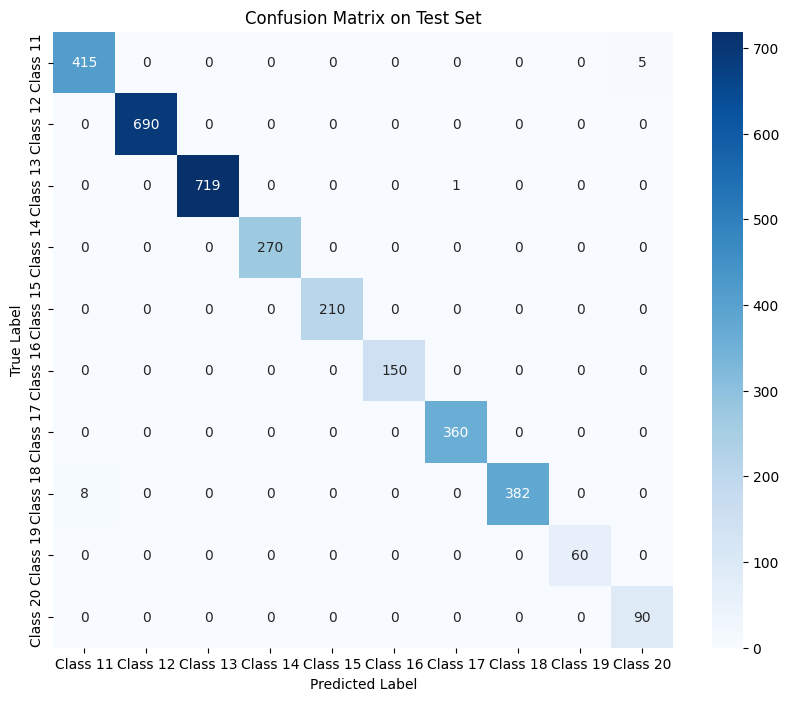

In [16]:
# Plot Confusion Matrix
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[f'Class {i+11}' for i in range(10)], yticklabels=[f'Class {i+11}' for i in range(10)])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix on Test Set')
plt.show()

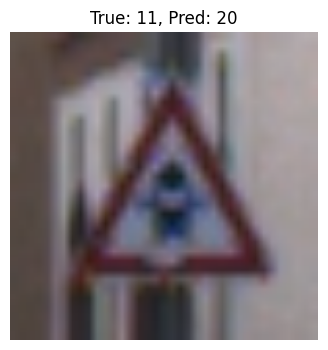

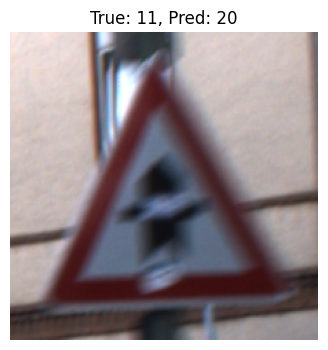

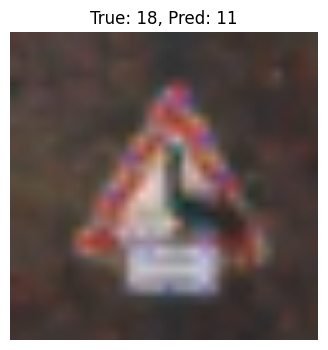

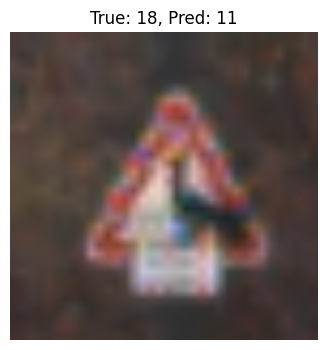

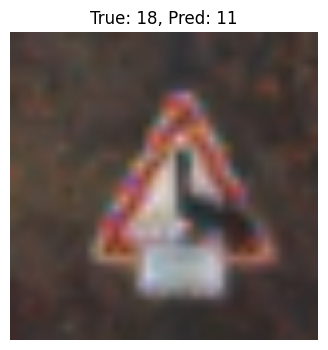

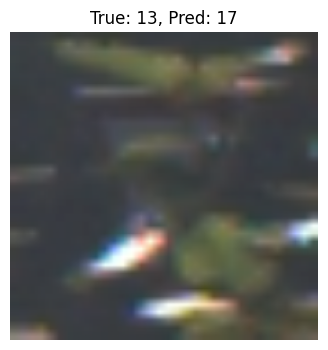

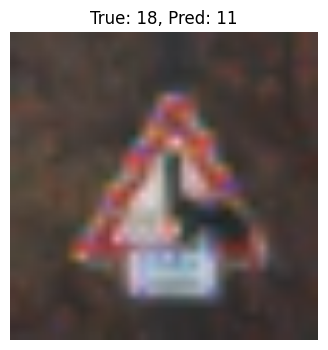

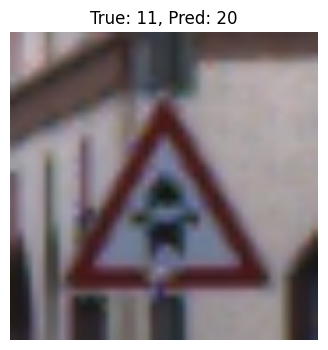

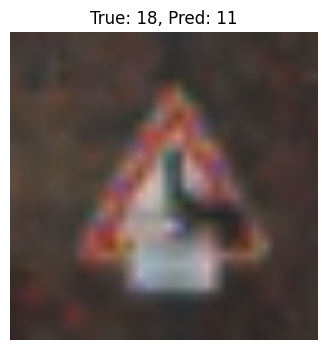

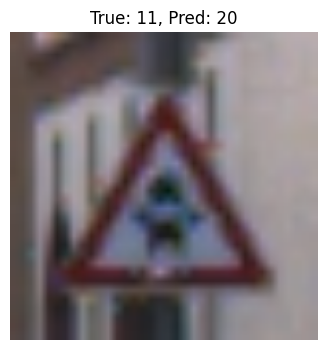

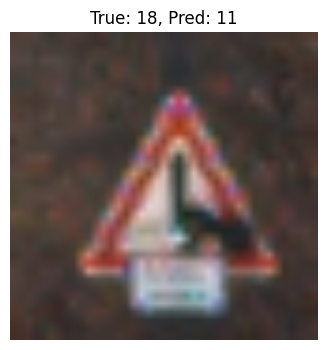

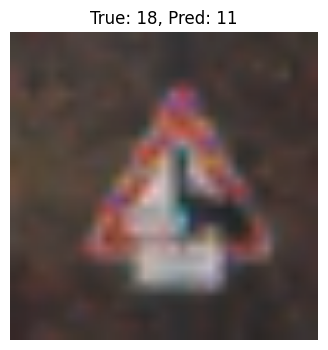

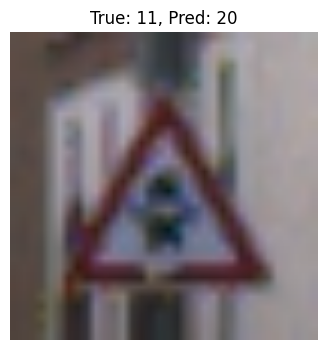

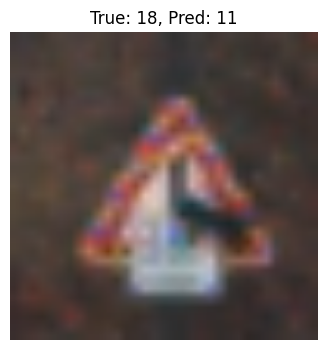

In [19]:
misclassified_indices = [i for i in range(len(all_labels)) if all_labels[i] != all_preds[i]]

num_to_plot = len(misclassified_indices)

if num_to_plot > 0:
    for i in range(num_to_plot):
        idx = misclassified_indices[i]
        img, true_label = test_dataset[idx]
        pred_label = all_preds[idx]
        true_class = true_label + 11  # Map back to 11-20
        pred_class = pred_label + 11
        title = f'True: {true_class}, Pred: {pred_class}'
        
        # Denormalize
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        denorm_img = img * std + mean
        denorm_img = torch.clamp(denorm_img, 0, 1)
        npimg = denorm_img.numpy()
        
        plt.figure(figsize=(4, 4))
        plt.imshow(np.transpose(npimg, (1, 2, 0)))
        plt.title(title)
        plt.axis('off')
        plt.show()
else:
    print('No wrong case')

In [3]:
import torch
import torchvision.models as models

model = models.resnet18(pretrained=False)

# changing classes amount
model.fc = torch.nn.Linear(in_features=model.fc.in_features, out_features=10)
state_dict = torch.load('/kaggle/input/resnet18_epoch/pytorch/default/1/resnet18_gtsrb_epoch_5 (1).pt')

model.load_state_dict(state_dict)
total_params = sum(p.numel() for p in model.parameters())

print(total_params)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


11181642
